In [1]:
"""
Este código compila os gráficos gerados para o trabalho da disciplina de 
Algoritmos e Estruturas de Dados II, com o tema: Árvores B e B+
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
ordem_vars = ['B-tree', 'B+ tree']

# 1. Carregar os dados (substitua pelo nome do seu arquivo)
df = pd.read_csv('all_benchmarks.csv')

# 2. Configuração visual do Seaborn
sns.set_theme(style="whitegrid")
sns.set(font_scale=0.8)
tam_fonte = 15
tam_fonte_titulo = 15

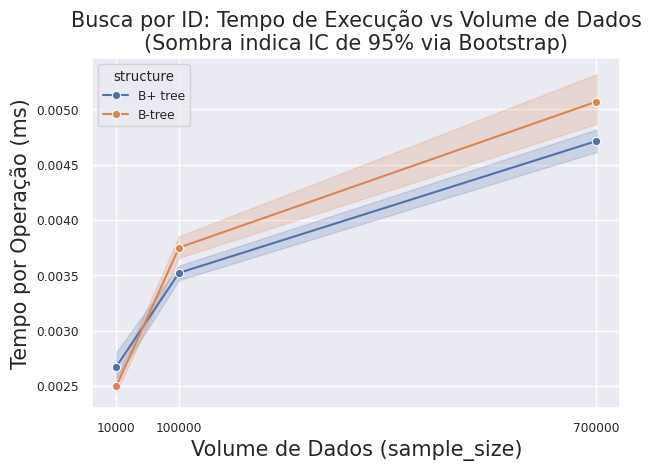

In [3]:
#Gráficos divididos por sessão:

#5.2. Busca pontual por identificador

# Tempo médio na busca por ID pelo volume de dados
df_filtrado_32= df[df['order'] == 32]
df_id_max = df_filtrado_32[(df_filtrado_32['operation'] == 'search_by_id') & (df_filtrado_32['sample_size'] == 700000)]


# Busca por ID (Tempo de Execução) 
plt.figure()
df_id = df[df['operation'] == 'search_by_id']
sns.lineplot(
    data=df_id, 
    x='sample_size', 
    y='time_per_operation_ms', 
    hue='structure',
    marker='o',
    errorbar=('ci', 95),
    n_boot=1000
)
plt.title('Busca por ID: Tempo de Execução vs Volume de Dados\n(Sombra indica IC de 95% via Bootstrap)', fontsize=tam_fonte_titulo)
plt.xlabel('Volume de Dados (sample_size)', fontsize=tam_fonte)
plt.ylabel('Tempo por Operação (ms)', fontsize=tam_fonte)
plt.xticks([10000, 100000, 700000])
plt.tight_layout()
plt.savefig('grafico_busca_id.png', dpi=300)
plt.show()

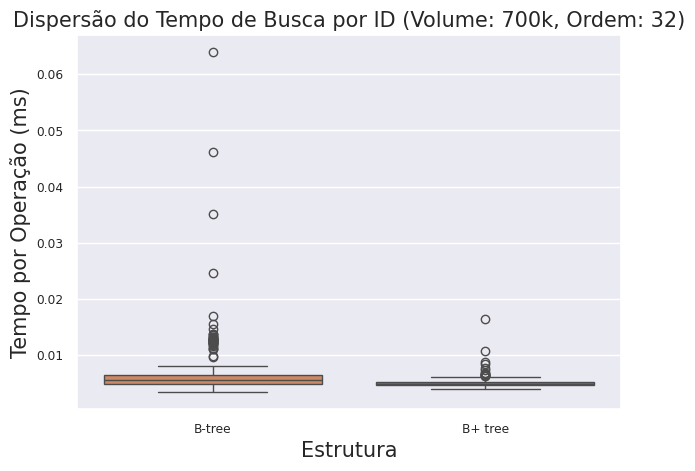

In [4]:
# Dispersão dos tempos de busca por ID
plt.figure()
sns.boxplot(
    data=df_id_max, 
    x='structure', 
    y='time_per_operation_ms',
    hue='structure',
    order=ordem_vars
)
plt.title('Dispersão do Tempo de Busca por ID (Volume: 700k, Ordem: 32)', fontsize=tam_fonte_titulo)
plt.xlabel('Estrutura', fontsize=tam_fonte)
plt.ylabel('Tempo por Operação (ms)', fontsize=tam_fonte)
plt.tight_layout()
plt.savefig('grafico_boxplot_tempo.png', dpi=300)
plt.show()

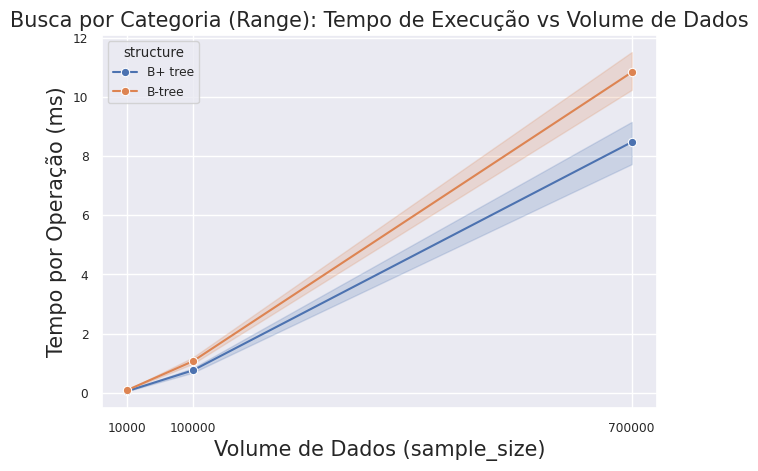

In [5]:
#5.3. Buscas por gênero e por título

# Tempo médio na busca por categoria 
plt.figure()
df_cat = df[(df['operation'] == 'search_by_category')]

sns.lineplot(
    data=df_cat,
    estimator=np.median,
    x='sample_size', 
    y='time_per_operation_ms', 
    hue='structure',
    marker='o',
    errorbar=('ci', 95), #uso de bootstrap para cálculo de intervalo de confiança
    n_boot=1000, # Número de amostragens do Bootstrap
)
plt.title('Busca por Categoria (Range): Tempo de Execução vs Volume de Dados', fontsize=tam_fonte_titulo)
plt.xlabel('Volume de Dados (sample_size)', fontsize=tam_fonte)
plt.ylabel('Tempo por Operação (ms)', fontsize=tam_fonte)
plt.xticks([10000,100000,700000])
plt.tight_layout()
plt.savefig('grafico_busca_categoria.png', dpi=300)
plt.show()

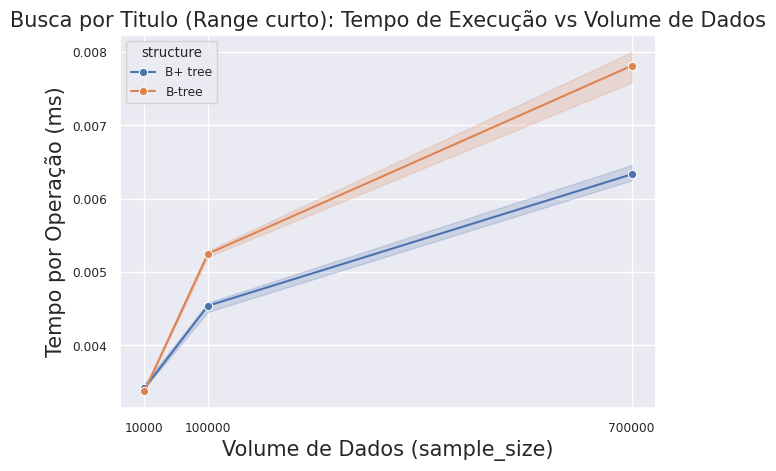

In [6]:
# Tempo médio na busca por titulo 
plt.figure()
df_cat = df[(df['operation'] == 'search_by_title')]

sns.lineplot(
    data=df_cat,
    estimator=np.median,
    x='sample_size', 
    y='time_per_operation_ms', 
    hue='structure',
    marker='o',
    errorbar=('ci', 95), #uso de bootstrap para cálculo de intervalo de confiança
    n_boot=1000, # Número de amostragens do Bootstrap
)
plt.title('Busca por Titulo (Range curto): Tempo de Execução vs Volume de Dados', fontsize=tam_fonte_titulo)
plt.xlabel('Volume de Dados (sample_size)', fontsize=tam_fonte)
plt.ylabel('Tempo por Operação (ms)', fontsize=tam_fonte)
plt.xticks([10000,100000,700000])
plt.tight_layout()
plt.savefig('grafico_busca_titulo.png', dpi=300)
plt.show()

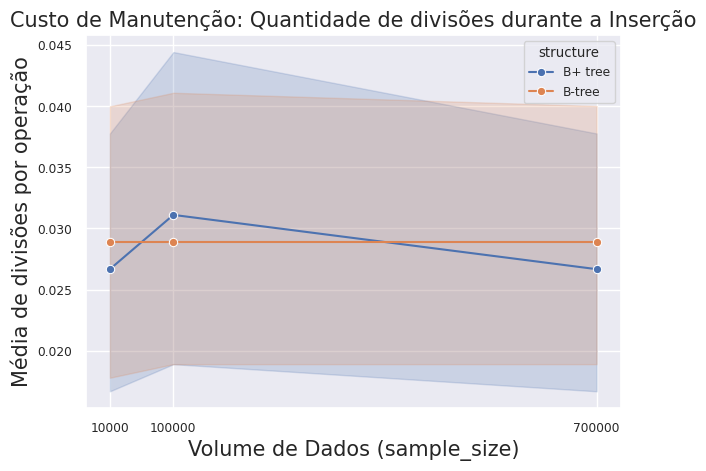

In [7]:
#5.4. Inserção de registros

# Quantidade de divisões na inserção
plt.figure()
df_insert = df[df['operation']=='insert_catalog']

sns.lineplot(
    data=df_insert, 
    x='sample_size', 
    y='splits', 
    hue='structure',
    marker='o',
    errorbar=('ci', 95),
    n_boot=1000,
    hue_order=['B+ tree','B-tree']
)
plt.title('Custo de Manutenção: Quantidade de divisões durante a Inserção', fontsize=tam_fonte_titulo)
plt.xlabel('Volume de Dados (sample_size)', fontsize=tam_fonte)
plt.ylabel('Média de divisões por operação', fontsize=tam_fonte)
plt.xticks([10000,100000,700000])
plt.tight_layout()
plt.savefig('grafico_splits_insercao.png', dpi=300)
plt.show()

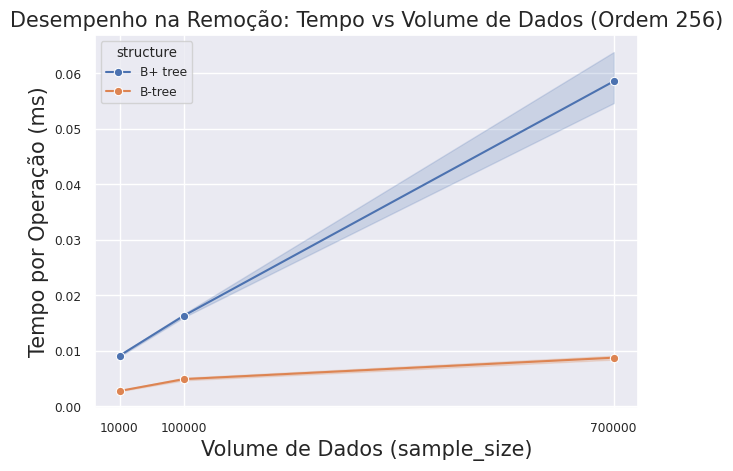

In [8]:
#5.5 Remoção de registros

# Tempo médio na remoção pelo volume de dados (Ordem fixada em 256)

df_remocao_256 = df[(df['operation'] == 'delete_catalog') & (df['order'] == 256)]

plt.figure()
sns.lineplot(
    data=df_remocao_256, 
    x='sample_size', 
    y='time_per_operation_ms', 
    hue='structure',
    marker='o',
    errorbar=('ci', 95),
    n_boot=1000,
    hue_order=['B+ tree','B-tree']
)
plt.title('Desempenho na Remoção: Tempo vs Volume de Dados (Ordem 256)', fontsize=tam_fonte_titulo)
plt.xlabel('Volume de Dados (sample_size)', fontsize=tam_fonte)
plt.ylabel('Tempo por Operação (ms)', fontsize=tam_fonte)
plt.xticks([10000, 100000, 700000])
plt.tight_layout()
plt.savefig('grafico_remocao_volume.png', dpi=300)
plt.show()